In [1]:
import ploting as draw
from utils import *
import pandas as pd

In [2]:
df = pd.read_csv("../data/2_feature/2feat_0seed_0.2err_obs-unc-tru.csv")
# draw.draw_combined_world(df, cmap="viridis")
shuffled_df = df.sample(frac=1).reset_index(drop=True)

In [21]:
df.iloc[[1, 2, 10000, 10001, 20000, 20001, 30000, 30001]]

,Observed Value 1,Uncertainty 1,Observed Value 2,Uncertainty 2,Class,True Value 1,True Value 2
1,-0.596529,0.199292,-0.600546,0.145429,0,-0.397237,-0.455117
2,-0.714323,0.137978,-0.196672,0.157434,0,-0.576345,-0.354106
10000,-0.731377,0.123550,0.117317,0.076160,1,-0.607827,0.041157
10001,-0.253280,0.176581,0.420111,0.013876,1,-0.076699,0.406235
20000,0.383359,0.014103,-0.957635,0.168961,2,0.369256,-0.788674
20001,0.638522,0.161618,-0.799321,0.118444,2,0.476905,-0.917766
30000,0.932792,0.004838,0.951998,0.049061,3,0.927955,0.902937
30001,0.515412,0.087795,0.640493,0.129687,3,0.427617,0.510806


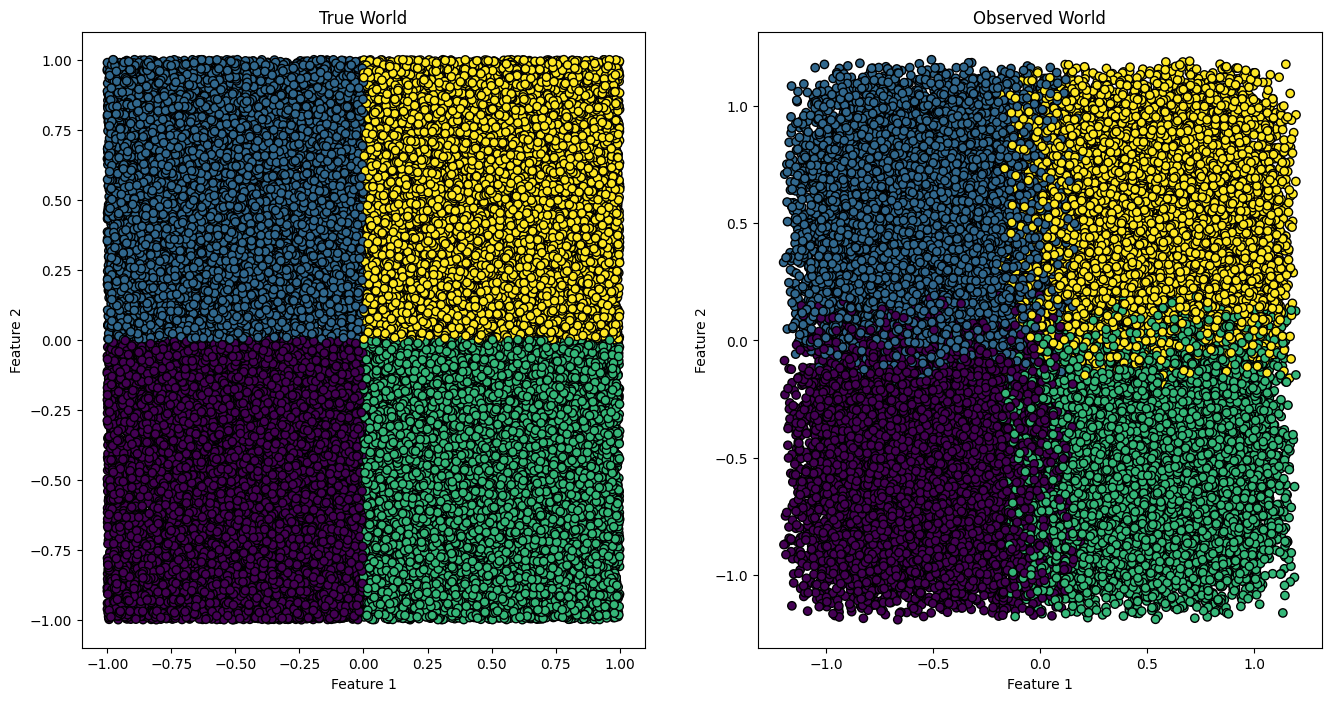

In [3]:
draw.draw_combined_world(shuffled_df)

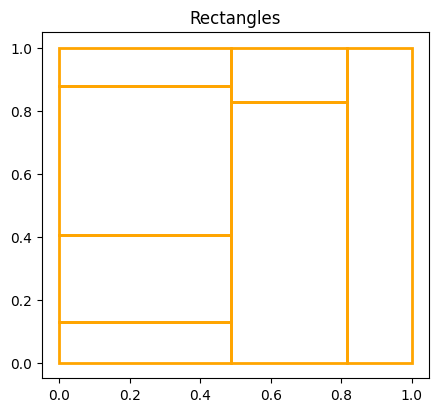

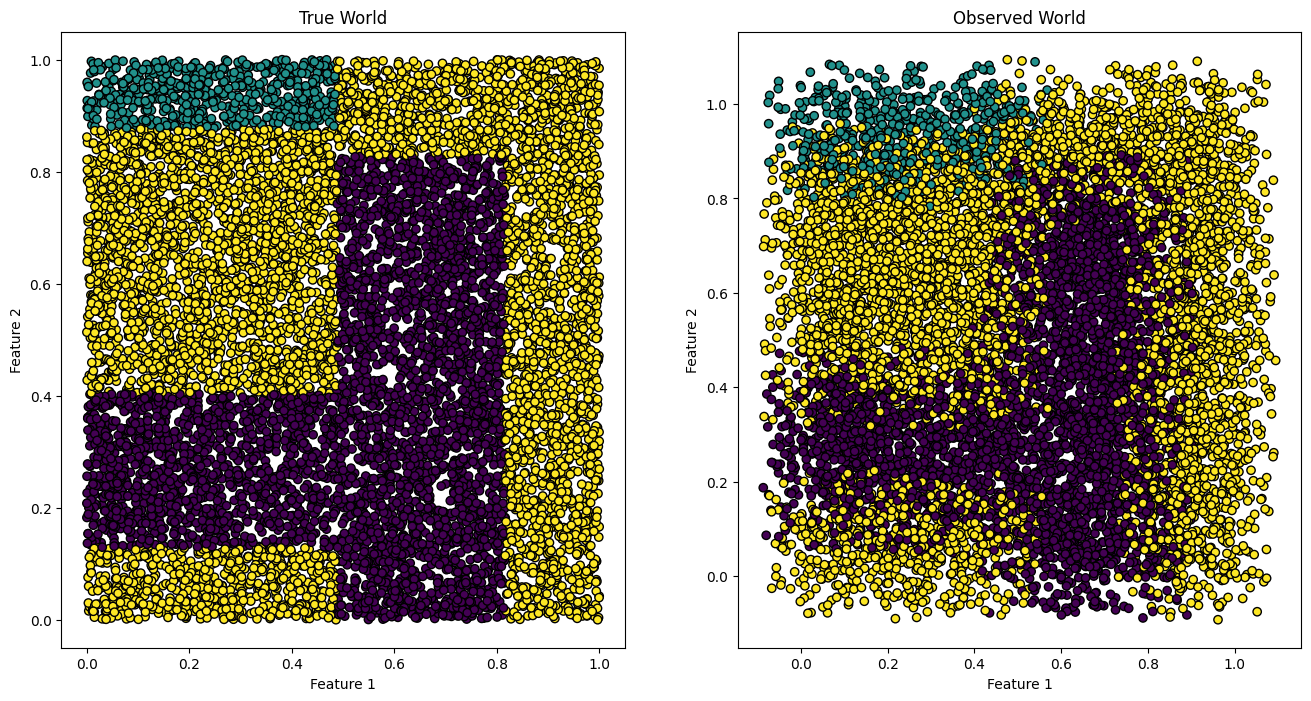

In [3]:
seed = 6
random.seed(seed )
world_coords = generate_world_bounds(2, endThreshold=0.1, endArea=0.3)
draw.draw_world_grid(world_coords, ((-0.05, 1.05),(-0.05, 1.05)))
world = generate_world_pandas(seed , seed , 2, endThreshold=0.1, endArea=0.3, class_number=3)
draw.draw_combined_world(world)

In [4]:
from uncertain.util.uncertaintreelearner import UncertainTreeLearner
from uncertain.util.uncertainforestutil import UncertainForestLearner
from uncertain.owtree import ClassificationTreeLearner
from Orange.modelling import RandomForestLearner
from Orange.classification.logistic_regression import LogisticRegressionLearner
from Orange.modelling.constant import ConstantLearner

post_hoc = UncertainTreeLearner(max_depth=None, min_samples_leaf=2, min_samples_split=4, sufficient_majority=0.90, post_hoc=True)
skl_tree = ClassificationTreeLearner(max_depth=None, min_samples_leaf=2, min_samples_split=4, sufficient_majority=0.90)
uncertain_forest = UncertainForestLearner(n_trees=10, max_depth=None, min_samples_split=4, post_hoc=True)
random_forest = RandomForestLearner(n_trees=10, max_depth=None, min_samples_split=4, max_features = None)
logistic_regression = LogisticRegressionLearner(penalty=None)
majority = ConstantLearner()

In [ ]:
from Orange.evaluation import TestOnTestData
from Orange.evaluation.scoring import CA

def add_noise(world, errRange = 1, mutation_rate = 0):
    _, n_feat = world[:, 1:].shape
    for i, cls_feat in enumerate(world):
        mutation = True if random.random() < mutation_rate else False
        if mutation:
            for j in range(1, n_feat + 1):
                cls_feat[j] = random.random() + errRange * random.uniform(-1, 1)
        else:
            for j in range(1, n_feat + 1):
                cls_feat[j] += errRange * random.uniform(-1, 1)
        world[i] = cls_feat
    return world

def get_world_results(seed, features, errRange, NUMBER_OF_CLASSES, n_sample, rep): 
    results = []
    for err_range in errRange:
        print(f"  World Seed {seed}, errRange {err_range}")
        np.random.seed(seed)
        world = generate_world(seed, seed, features, 
                            feature_bounds = (0, 1), 
                            endThreshold = .1, endArea = .3,
                            class_number = NUMBER_OF_CLASSES,
                            errRange = err_range, corr = 1)
        
        # world = world[world[:,0] != 0] ## odstani če ne delaš mankajočih clasov
        
        data, test_data = convert_np_to_orange(world, features)
        # world = add_noise(world, errRange=0.05, mutation_rate=0.1)
        # data, _ = convert_np_to_orange(world, features)
        for samples_per_class in n_sample:
            average_CA = np.array([0, 0, 0, 0], dtype="float64")
            majority_class = CA(TestOnTestData(test_data, test_data=test_data, learners=[majority]))[0]
            for _ in range(rep):
                res = TestOnTestData(data=sample_data_orange(data, samples_per_class), test_data=test_data, learners=[skl_tree, post_hoc, uncertain_forest, random_forest])
                print(CA(res))
                average_CA += CA(res)
                # print(sample_data_orange(data, samples_per_class))
                # print(f"    samples_per_class: {samples_per_class}\n    Results:")
            average_CA = average_CA / rep * 100
            results.append([features, seed, err_range, samples_per_class, average_CA[0], average_CA[1], average_CA[2], average_CA[3], majority_class])
            # print(f"  Results {samples_per_class}:\n      skl_tree          {round(average_CA[0], 2)}%\n      post_hoc          {round(average_CA[1], 2)}%\n      uncertain_forest  {round(average_CA[2], 2)}%")
    return results
            

In [8]:
get_world_results(
    seed = 6,
    features = 2,
    errRange = list(np.arange(0, 11) / 10),
    NUMBER_OF_CLASSES = 3,
    n_sample = [20],
    rep=33)

  World Seed 6, errRange 0.0


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [12]:
world

,Class,True Value 1,True Value 2,Observed Value 1,Uncertainty 1,Error 1,Observed Value 2,Uncertainty 2,Error 2
0,0.0,0.757370,0.401831,0.835942,0.078572,0.078572,0.367977,0.033854,-0.033854
1,2.0,0.488176,0.942159,0.454572,0.033604,-0.033604,1.005982,0.063822,0.063822
2,0.0,0.370770,0.232017,0.435015,0.064246,0.064246,0.323037,0.091020,0.091020
3,0.0,0.577387,0.664353,0.485726,0.091661,-0.091661,0.645307,0.019046,-0.019046
4,0.0,0.623691,0.445963,0.545223,0.078469,-0.078469,0.470345,0.024382,0.024382
...,...,...,...,...,...,...,...,...,...
9995,2.0,0.266650,0.785002,0.274370,0.007720,0.007720,0.693053,0.091950,-0.091950
9996,0.0,0.663624,0.697747,0.759890,0.096266,0.096266,0.789413,0.091666,0.091666
9997,2.0,0.971416,0.971259,0.949602,0.021814,-0.021814,0.920985,0.050274,-0.050274
9998,0.0,0.705976,0.455644,0.641696,0.064280,-0.064280,0.424996,0.030649,-0.030649


/tmp/ipykernel_30206/1884250453.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(10))


Text(0.5, 1.0, 'Sample of Observed World')

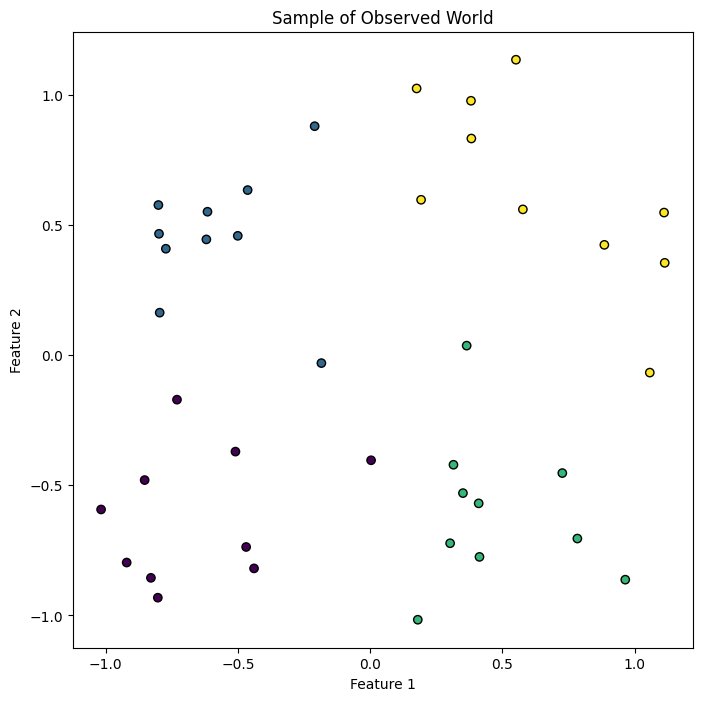

In [26]:
import matplotlib.pyplot as plt

df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(10))

x = df["Observed Value 1"]
y = df["Observed Value 2"]
classes = df["Class"]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, c=classes, cmap="viridis", edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sample of Observed World')

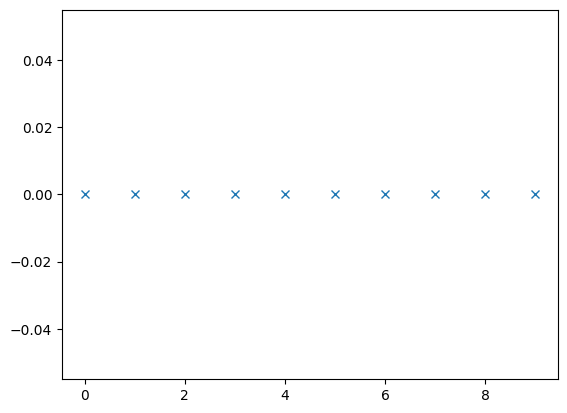

In [3]:
import numpy as np
import matplotlib.pyplot as plt
val = 0. # this is the value where you want the data to appear on the y-axis.
ar = np.arange(10) # just as an example array
plt.plot(ar, np.zeros_like(ar) + val, 'x')
plt.show()

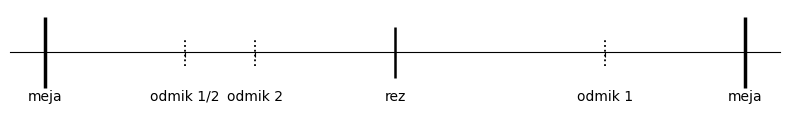

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Positions of vertical lines
positions = np.array([0, 0.2, 0.3, 0.5, 0.8, 1.0])

fig, ax = plt.subplots(figsize=(8, 1.2))

# Draw vertical lines with requested styles
for x in positions:
    if x in [0, 1]:
        # Big solid lines
        ax.vlines(x, -0.25, 0.25, color='black', linewidth=2.5)
    elif np.isclose(x, 0.5):
        # Medium solid line
        ax.vlines(x, -0.18, 0.18, color='black', linewidth=1.8)
    else:
        # Dotted shorter lines
        ax.vlines(x, -0.1, 0.1, color='black', linewidth=1.3, linestyles='dotted')

# Clean up axes
ax.get_yaxis().set_visible(False)

# Set tick positions and custom labels
labels = [
    "meja",
    "odmik 1/2",
    "odmik 2",
    "rez",
    "odmik 1",
    "meja"
]
ax.set_xticks(positions)
ax.set_xticklabels(labels)

# Hide other spines and align bottom spine with y=0
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))

# Move x-tick labels downward (adjust pad as desired)
ax.tick_params(axis='x', which='both', pad=23)

# Limits and layout
ax.set_xlim(positions.min() - 0.05, positions.max() + 0.05)
ax.set_ylim(-0.3, 0.3)
plt.tight_layout()
plt.savefig("odmik.pdf")

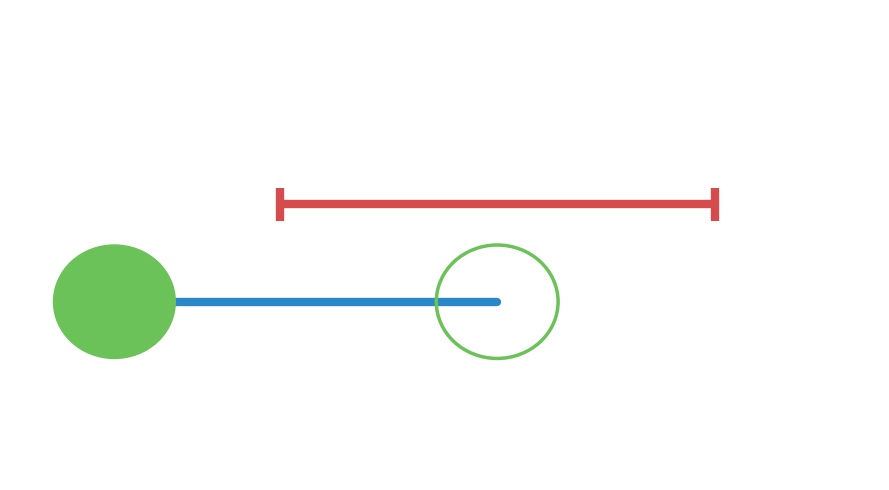

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Simple stylized illustration similar to the provided sketch
fig, ax = plt.subplots(figsize=(9, 5))

# Coordinates (moved a bit right so elements sit nicely in the frame)
start = np.array([0.12, 0.5])   # green dot center
end = np.array([0.56, 0.5])     # blue line end / ring center

# Make both green circles the same (smaller) radius
green_radius = 0.07

# Large filled green circle at the left
green_circle = Circle(start, green_radius, color='#6ac259', zorder=4)
ax.add_patch(green_circle)

# Thick blue horizontal 'pipe' from the green circle towards the right
blue_start_x = start[0] + green_radius * 0.9
# Move the blue line all the way to the center of the transparent circle
blue_end_x = end[0]
ax.plot([blue_start_x, blue_end_x], [start[1], end[1]], color='#2a87c8', linewidth=6, solid_capstyle='round', zorder=3)

# Continuous green ring at the end (outline circle) - same (smaller) radius as filled green circle
ring_r = green_radius
green_ring = Circle(end, ring_r, edgecolor='#6ac259', facecolor='none', linewidth=2.5, zorder=5)
ax.add_patch(green_ring)

# Red long line above (main segment) - make it shorter and center it on the right circle
red_y = 0.62   # vertical position of the red line
red_length = 0.5  # total horizontal length of the red line
red_left = end[0] - red_length/2
red_right = end[0] + red_length/2
ax.plot([red_left, red_right], [red_y, red_y], color='#d64b4b', linewidth=6, solid_capstyle='butt', zorder=2)

# Draw short vertical dash segments at the ends instead of round dots
# (kept relatively small so they look like end-caps)
dash_len = 0.04  # total length of the dash (vertical)
dash_width = 6   # thickness of the dash
# left vertical dash centered at red_left
ax.plot([red_left, red_left], [red_y - dash_len/2, red_y + dash_len/2], color='#d64b4b', linewidth=dash_width, solid_capstyle='butt', zorder=3)
# right vertical dash centered at red_right
ax.plot([red_right, red_right], [red_y - dash_len/2, red_y + dash_len/2], color='#d64b4b', linewidth=dash_width, solid_capstyle='butt', zorder=3)

# Fine tuning: hide axes and set limits (tighter vertical range so lines appear close)
ax.set_xlim(0, 1)
ax.set_ylim(0.28, 0.86)
ax.axis('off')
plt.tight_layout()
plt.show()
